# Importing Libraries

In [1]:
%%capture
!pip install pyreft
!pip install -U transformers
!pip install torchinfo
!pip install nnsight

In [2]:
def is_kaggle():
  return True

import json
import glob
import os
import statistics
import collections

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr, pearsonr

import torch
import transformers
import pyreft
import torchinfo
from torchinfo import summary
from transformers import AutoModelForCausalLM, AutoTokenizer
from accelerate import Accelerator

if not is_kaggle():
  !pip install gdown

import gdown
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Loading Data

In [3]:
%%capture
output_path = "/content/data" if not is_kaggle() else "/kaggle/working/data"

data_zip, output_data_zip = f"{output_path}/data.zip", f"{output_path}/data"
weights_zip, output_weights_zip = f"{output_path}/weights.zip", f"{output_path}/weights"

!gdown --folder "https://drive.google.com/drive/folders/1PIltIlM8mBF6xVKEf9EotaF9qNVofHNp?usp=sharing" -O {output_path}
!unzip {data_zip} -d {output_data_zip}
!unzip {weights_zip} -d {output_weights_zip}

# Compiling Data

In [4]:
WEIGHTS_PATH = f"{output_weights_zip}/weights"
DATA_PATH = f"{output_data_zip}/data"

In [5]:
def prepare_data(folder_name, decoder=True):
  folder_path = f"{DATA_PATH}/{folder_name}"
  json_files = glob.glob(os.path.join(folder_path, '*.json'))

  data_list = []

  for file_path in json_files:
      with open(file_path, 'r') as f:
          data = json.load(f)
          if decoder:
              history = data.get('history')[:-1]
            
              extracted_data = {
                  'layer_idx': data.get('layer_idx'),
                  'epoch_losses': [item["loss"] for item in history],
                  'grad_norms': [item["grad_norm"] for item in history],
                  'score': data.get('score'),
                  'seed': data.get('seed'),
                  'predictions': data.get('predictions')
              }
          else:
              extracted_data = {
                  'layer_idx': data.get('layer_idx'),
                  'epoch_losses': data.get('train_losses'),
                  'score': data.get('score'),
                  'seed': data.get('seed')
              }

          data_list.append(extracted_data)

  data_list.sort(key=lambda x: x['layer_idx'])

  df = pd.DataFrame(data_list)
  return df

In [6]:
dataframes = {}
models, datasets = ["qwen", "granite"], ["hellaswag", "sst2"]

for model in models:
    for dataset in datasets:
        key = f"{model}-{dataset}"
        dataframes[key] = prepare_data(key)


for model in ["roberta"]:
    for dataset in ["mnli", "qqp"]:
        key = f"{model}-{dataset}"
        dataframes[key] = prepare_data(key, decoder=False)

In [7]:
# dataframes["granite-hellaswag"].at[1, 'score'] = 0.34
# dataframes['granite-hellaswag'].at[1, 'predictions'] = dataframes['granite-hellaswag'].iloc[0].predictions

# Analysis

In [8]:
def layer_vs_accuracy_plot(accuracies, layers, save=False, save_filename=None):
    plt.figure()
    
    # Main accuracy curve
    plt.plot(
        layers,
        accuracies,
        linewidth=2,
        marker='o',
        markersize=4,
        label='ReFT Accuracy'
    )
    
    # Highlight early / middle / late layers
    plt.axvspan(0, len(layers) * 1 / 3, alpha=0.08)
    plt.axvspan(len(layers) * 1 / 3, len(layers) * 2 / 3, alpha=0.08)
    plt.axvspan(len(layers) * 2 / 3, len(layers), alpha=0.08)
    
    # Region separators
    plt.axvline(x=len(layers) * 1 / 3, linestyle='--', linewidth=1)
    plt.axvline(x=len(layers) * 2 / 3, linestyle='--', linewidth=1)
    
    plt.xlabel("Transformer Layer Index")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Layer-wise ReFT Performance")
    plt.xticks(np.arange(0, len(layers), 4))
    plt.grid(alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    if not save:
        return

    if not save_filename:
        raise "save_filename is required if you want to save the plot"

    plt.savefig(save_filename, dpi=300, bbox_inches="tight")

def layer_vs_accuracy_plot_save(key):
    accuracies, layers = dataframes[key].score, dataframes[key].layer_idx

    layer_vs_accuracy_plot(accuracies, layers, save=True, save_filename=f"{key}-layer-vs-accuracy-plot.png")

## Layer-wise Accuracy

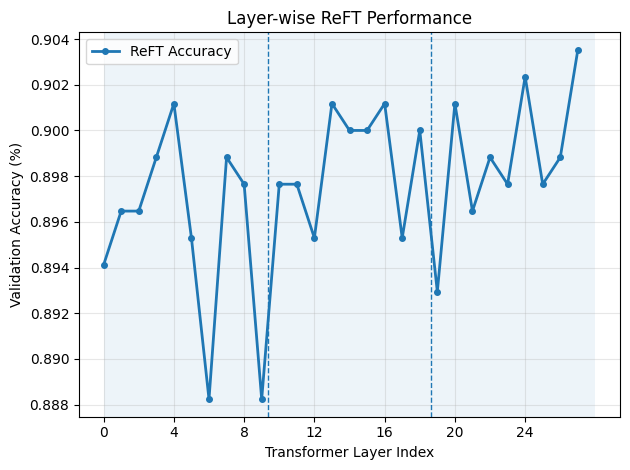

<Figure size 640x480 with 0 Axes>

In [9]:
layer_vs_accuracy_plot_save('granite-sst2')

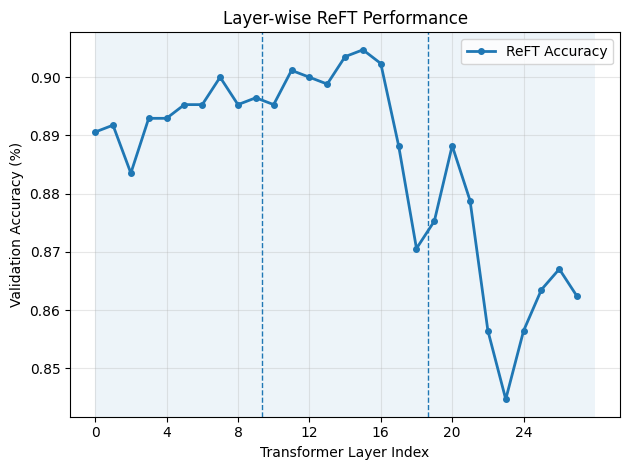

<Figure size 640x480 with 0 Axes>

In [10]:
layer_vs_accuracy_plot_save('qwen-sst2')

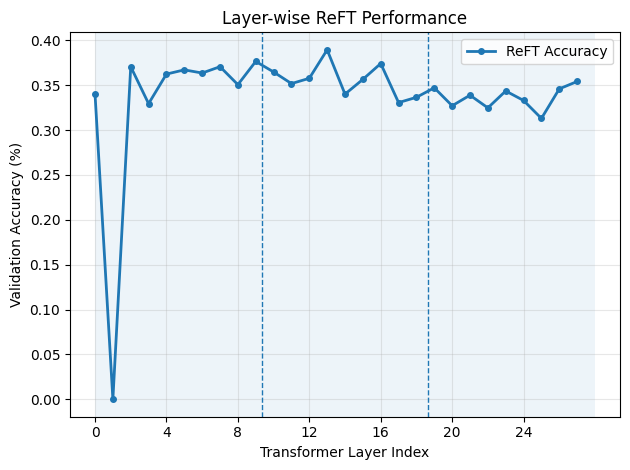

<Figure size 640x480 with 0 Axes>

In [11]:
layer_vs_accuracy_plot_save('granite-hellaswag')

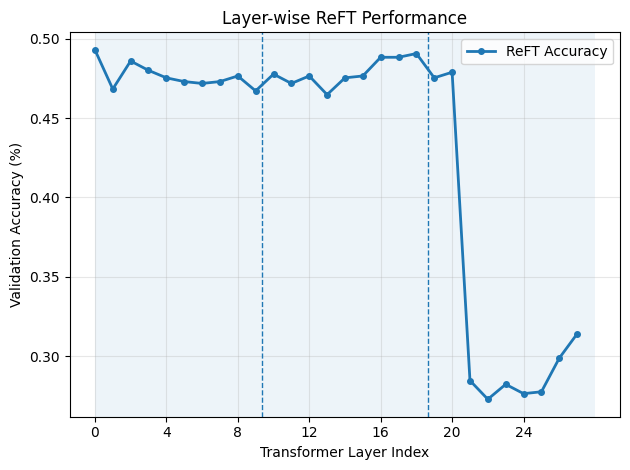

<Figure size 640x480 with 0 Axes>

In [12]:
layer_vs_accuracy_plot_save('qwen-hellaswag')

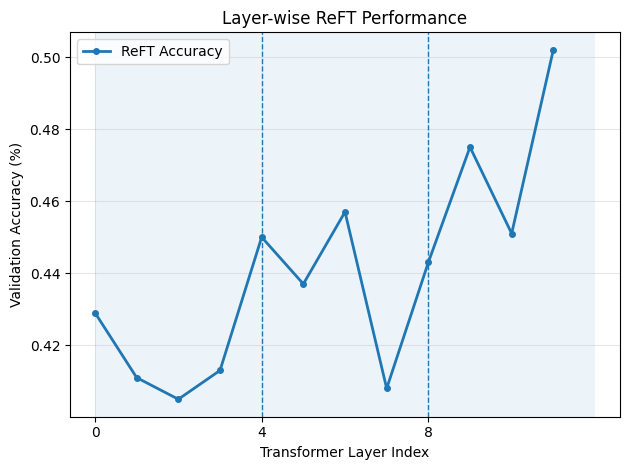

<Figure size 640x480 with 0 Axes>

In [13]:
layer_vs_accuracy_plot_save('roberta-mnli')

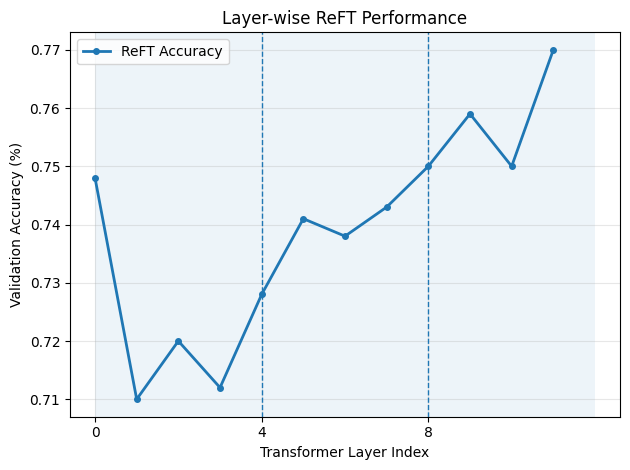

<Figure size 640x480 with 0 Axes>

In [14]:
layer_vs_accuracy_plot_save('roberta-qqp')

## Layer-wise Statistics

In [15]:
def stats(key):
    print(f"Key: {key}")    
    
    layers, scores = dataframes[key].layer_idx, dataframes[key].score
    data = dict(zip(layers, scores))
    
    print(f"Mean Accuracy: {statistics.mean(scores)}")
    print(f"Variance: {statistics.variance(scores)} \n")

    sorted_data = dict(sorted(data.items(), key=lambda item: item[1]))
    items = list(sorted_data.items())
    
    print("Layers with lowest accuracy:")
    for k, v in items[:2]:
        print(f"{k}: {v}")
    
    print("Layers with highest accuracy:")
    for k, v in items[-2:]:
        print(f"{k}: {v}")

    _, lowest_accuracy = items[0]
    _, highest_accuracy = items[-1]
    print(f"Accuracy Gains: {highest_accuracy - lowest_accuracy}")
    print("\n\n")
    return items

def grouped_stats(key, n):
    def chunk_list_by_n(data, n):
        return [data[i:i + n] for i in range(0, len(data), n)]

    def chunk_list_by_list(data, n_list):
        chunks = []
        start = 0
        for n in n_list:
            chunks.append(data[start : start + n])
            start += n
        return chunks

    print(f"Key: {key}")    
    
    layers, scores = dataframes[key].layer_idx, dataframes[key].score
    method = chunk_list_by_n if isinstance(n, int) else chunk_list_by_list
    layers, scores = method(layers, n), method(scores, n)

    data = [dict(zip(layers, scores)) for layers, scores in zip(layers, scores)]
    compiled_grouped_data = {}

    for d in data:
        layer_range, accuracy_range = list(d.keys()), list(d.values())
        mean_accuracy = statistics.mean(accuracy_range)

        print(f"Layer Range: {layer_range[0]}-{layer_range[-1]}")
        print(f"Mean Accuracy: {mean_accuracy} \n\n")

        compiled_grouped_data['-'.join([str(i) for i in layer_range])] = mean_accuracy

    return compiled_grouped_data

In [16]:
all_models = ['qwen-sst2', 'qwen-hellaswag', 'granite-sst2', 'granite-hellaswag', 'roberta-mnli', 'roberta-qqp']
decoder_models = ['qwen-sst2', 'qwen-hellaswag', 'granite-sst2', 'granite-hellaswag']

for key in all_models:
    stats(key)

Key: qwen-sst2
Mean Accuracy: 0.8854201680672269
Variance: 0.00028146500430237454 

Layers with lowest accuracy:
23: 0.8447058823529412
22: 0.8564705882352941
Layers with highest accuracy:
14: 0.9035294117647059
15: 0.9047058823529411
Accuracy Gains: 0.05999999999999994



Key: qwen-hellaswag
Mean Accuracy: 0.42978991596638655
Variance: 0.007168017795353435 

Layers with lowest accuracy:
22: 0.27294117647058824
24: 0.27647058823529413
Layers with highest accuracy:
18: 0.49058823529411766
0: 0.4929411764705882
Accuracy Gains: 0.21999999999999997



Key: granite-sst2
Mean Accuracy: 0.8976050420168067
Variance: 1.3377638637154239e-05 

Layers with lowest accuracy:
6: 0.888235294117647
9: 0.888235294117647
Layers with highest accuracy:
24: 0.9023529411764706
27: 0.9035294117647059
Accuracy Gains: 0.015294117647058902



Key: granite-hellaswag
Mean Accuracy: 0.3378151260504202
Variance: 0.004710979293678256 

Layers with lowest accuracy:
1: 0.0
25: 0.3129411764705882
Layers with highest acc

In [17]:
grouped_args = zip(all_models, [
    [10, 10, 8],
    [10, 10, 8],
    7,
    7,
    [3, 3, 4],
    [3, 3, 4]
])

for model_key, grouped_arg in grouped_args:
    grouped_stats(model_key, grouped_arg)

Key: qwen-sst2
Layer Range: 0-9
Mean Accuracy: 0.8934117647058823 


Layer Range: 10-19
Mean Accuracy: 0.894 


Layer Range: 20-27
Mean Accuracy: 0.8647058823529412 


Key: qwen-hellaswag
Layer Range: 0-9
Mean Accuracy: 0.4763529411764706 


Layer Range: 10-19
Mean Accuracy: 0.4784705882352941 


Layer Range: 20-27
Mean Accuracy: 0.31073529411764705 


Key: granite-sst2
Layer Range: 0-6
Mean Accuracy: 0.8957983193277311 


Layer Range: 7-13
Mean Accuracy: 0.8966386554621849 


Layer Range: 14-20
Mean Accuracy: 0.8986554621848739 


Layer Range: 21-27
Mean Accuracy: 0.899327731092437 


Key: granite-hellaswag
Layer Range: 0-6
Mean Accuracy: 0.30470588235294116 


Layer Range: 7-13
Mean Accuracy: 0.3658823529411765 


Layer Range: 14-20
Mean Accuracy: 0.3445378151260504 


Layer Range: 21-27
Mean Accuracy: 0.3361344537815126 


Key: roberta-mnli
Layer Range: 0-2
Mean Accuracy: 0.415 


Layer Range: 3-5
Mean Accuracy: 0.43333333333333335 


Layer Range: 6-9
Mean Accuracy: 0.44575 


Key: 

## Token Biases

In [18]:
def token_biases(key):
    df = dataframes[key]
    
    layers, predictions, scores = df.layer_idx, df.predictions, df.score
    
    data = dict(zip(layers, predictions))
    scores_dict = dict(zip(layers, scores))

    print(f"Key: {key}\n")
    for k, results in data.items():
        counts = collections.Counter(results)
        total = len(results)

        percentages = {k: round((v / total) * 100, 2) for k, v in counts.items()}
        sorted_percentages = dict(sorted(percentages.items(), key=lambda item: item[1], reverse=True))

        print(f"Layer: {k}")
        print(f"Layer Score: {scores_dict[k]}")
        print("Tally by Percentages:")
        for label, percent in sorted_percentages.items():
            print(f"{label}: {percent}%")
        print("\n\n")        

In [19]:
for key in decoder_models:
    token_biases(key)

Key: qwen-sst2

Layer: 0
Layer Score: 0.8905882352941177
Tally by Percentages:
positive: 53.41%
negative: 46.59%



Layer: 1
Layer Score: 0.8917647058823529
Tally by Percentages:
positive: 52.35%
negative: 47.65%



Layer: 2
Layer Score: 0.8835294117647059
Tally by Percentages:
positive: 52.24%
negative: 47.76%



Layer: 3
Layer Score: 0.8929411764705882
Tally by Percentages:
positive: 52.47%
negative: 47.53%



Layer: 4
Layer Score: 0.8929411764705882
Tally by Percentages:
positive: 53.18%
negative: 46.82%



Layer: 5
Layer Score: 0.8952941176470588
Tally by Percentages:
positive: 53.18%
negative: 46.82%



Layer: 6
Layer Score: 0.8952941176470588
Tally by Percentages:
positive: 52.24%
negative: 47.76%



Layer: 7
Layer Score: 0.9
Tally by Percentages:
positive: 52.71%
negative: 47.29%



Layer: 8
Layer Score: 0.8952941176470588
Tally by Percentages:
positive: 52.47%
negative: 47.53%



Layer: 9
Layer Score: 0.8964705882352941
Tally by Percentages:
positive: 51.88%
negative: 48.12%




## Loss Landscape / Optimization Behavior

In [20]:
# Set professional styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

def plot_layer_losses(loss_data_dict, model_name="Model", task_name="Task"):
    """
    loss_data_dict: { "Layer 5": [0.8, 0.6, 0.4...], "Layer 15": [...] }
    """
    plt.figure(figsize=(12, 7))
    
    palette = sns.color_palette("magma", len(loss_data_dict))
    
    for i, (layer_name, losses) in enumerate(loss_data_dict.items()):
        steps = np.arange(len(losses))
        sns.lineplot(
            x=steps, 
            y=losses, 
            label=layer_name, 
            color=palette[i], 
            alpha=0.8, 
            linewidth=2
        )
    title = f"ReFT Training Loss per Layer - {model_name} {task_name}"
    plt.title(title, fontsize=15, pad=20)
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    
    # plt.yscale('log')

    if len(loss_data_dict) > 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Intervention Layer", ncol=2)
    else:
        plt.legend(title="Layer Index")

    plt.tight_layout()
    plt.show()

from itertools import chain

def prepare_data_for_plot(
    key,
    metric='grad_norms',
    layer_range=[None, None], 
    multiple=False,
    truncate_data=None, 
):
    if multiple:
        layer_slices = [slice(start, end) for start, end in layer_range]
        df = dataframes[key].iloc[np.r_[*layer_slices]]
    else:
        df = dataframes[key].iloc[slice(*layer_range)]

    layers, column_data = list(df.layer_idx), list(df[metric])
    layers = [f"Layer {layer}" for layer in layers]

    if truncate_data:
        truncate_slices = [slice(start, end) for start, end in truncate_data]
        collected_data = []

        for row in column_data:
            truncated_row = list(chain.from_iterable(row[s] for s in truncate_slices))
            collected_data.append(truncated_row)
        
        column_data = collected_data

    return dict(zip(layers, column_data))

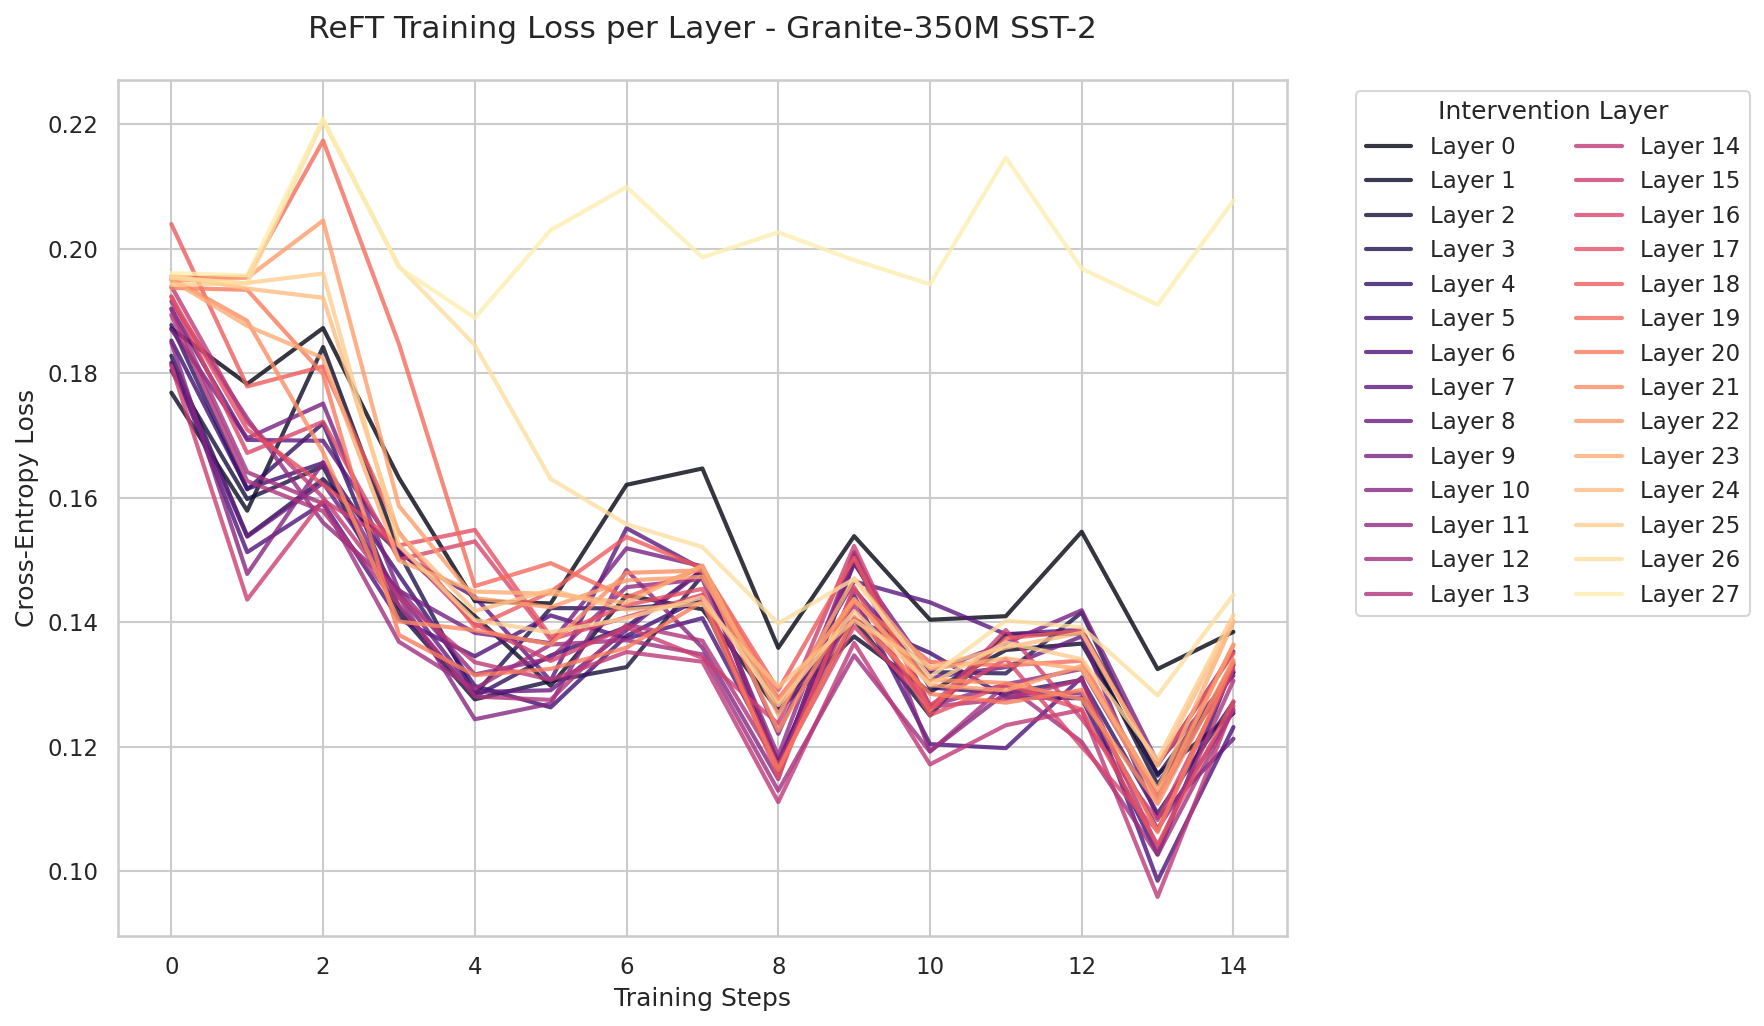

In [21]:
data = prepare_data_for_plot('granite-sst2', metric='epoch_losses')
plot_layer_losses(data, model_name="Granite-350M", task_name="SST-2")

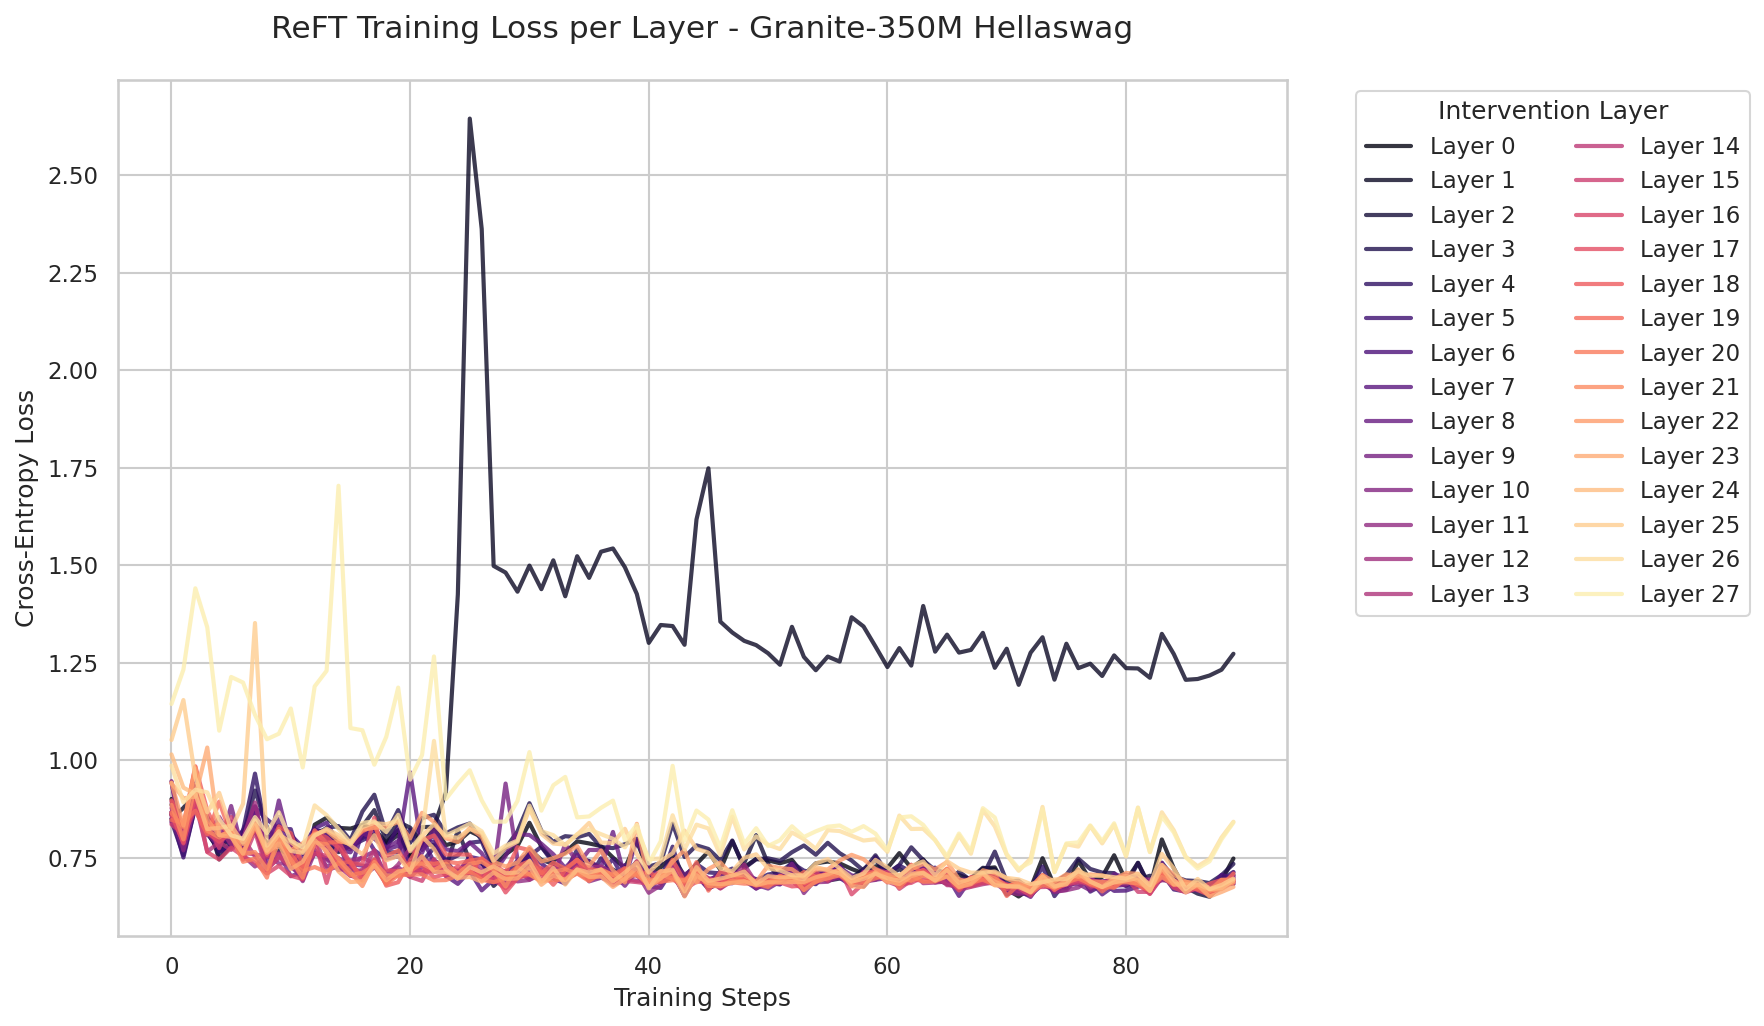

In [22]:
data = prepare_data_for_plot('granite-hellaswag', metric='epoch_losses')
plot_layer_losses(data, model_name="Granite-350M", task_name="Hellaswag")

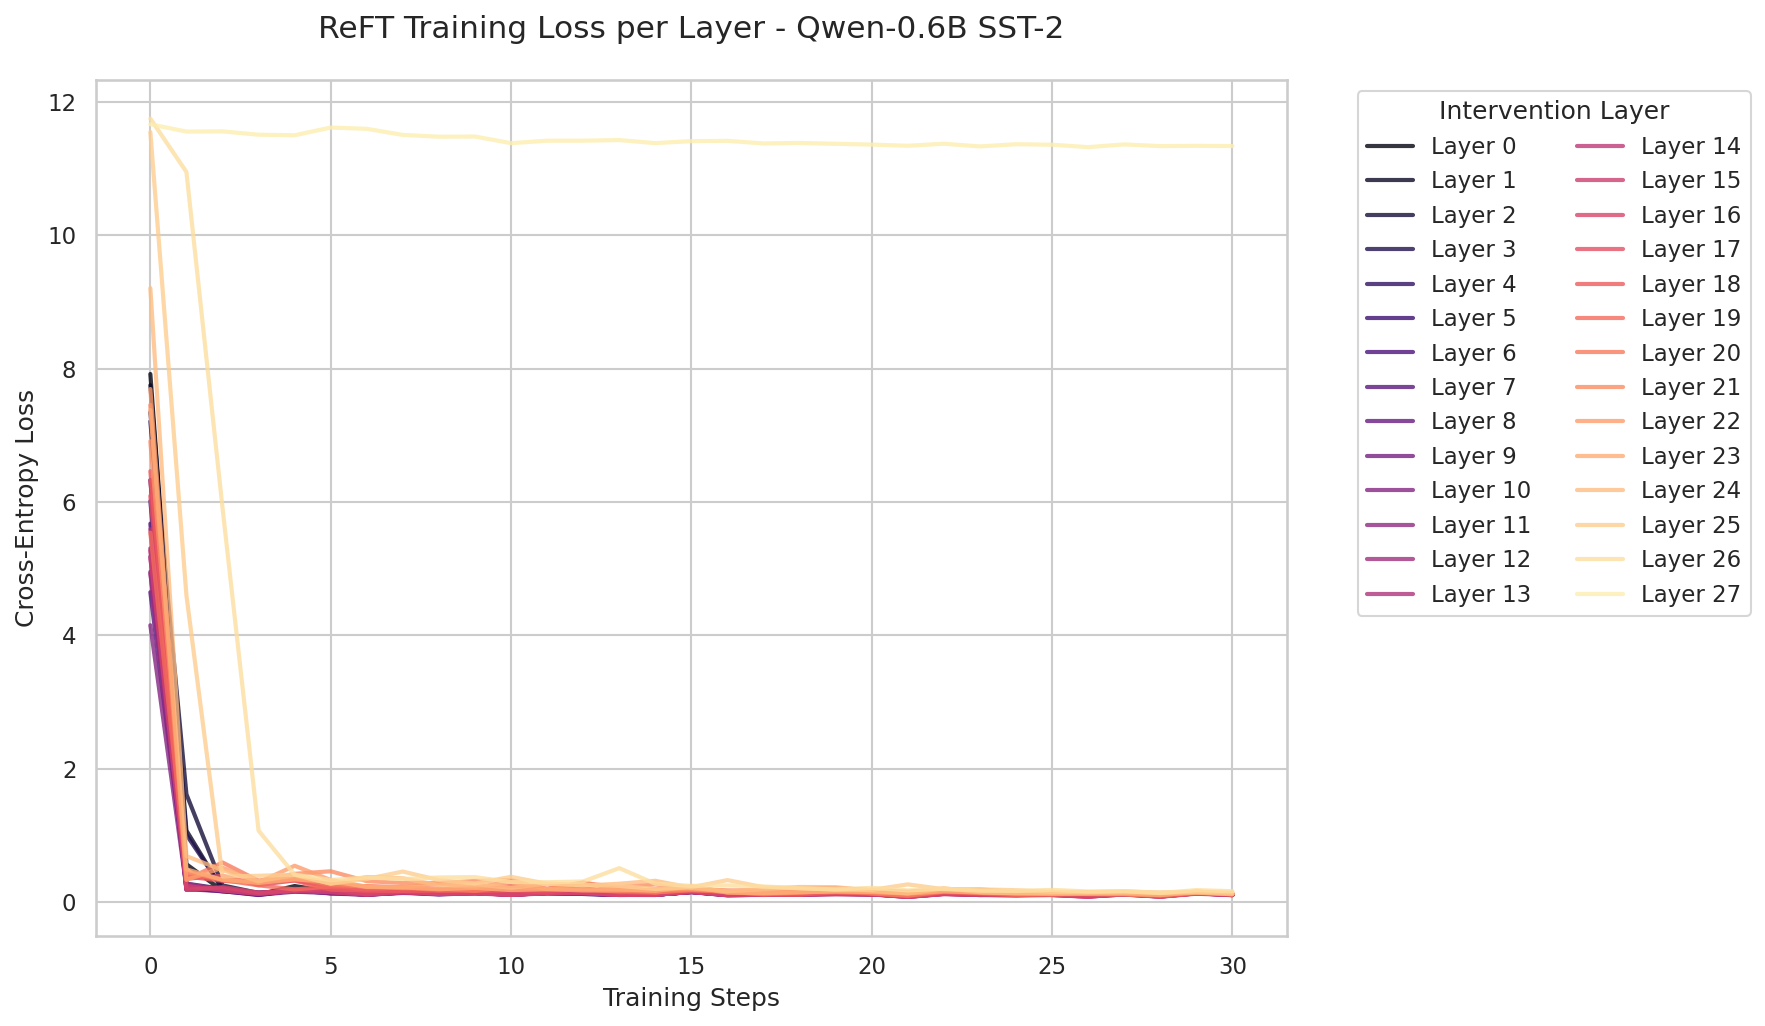

In [23]:
data = prepare_data_for_plot('qwen-sst2', metric='epoch_losses')
plot_layer_losses(data, model_name="Qwen-0.6B", task_name="SST-2")

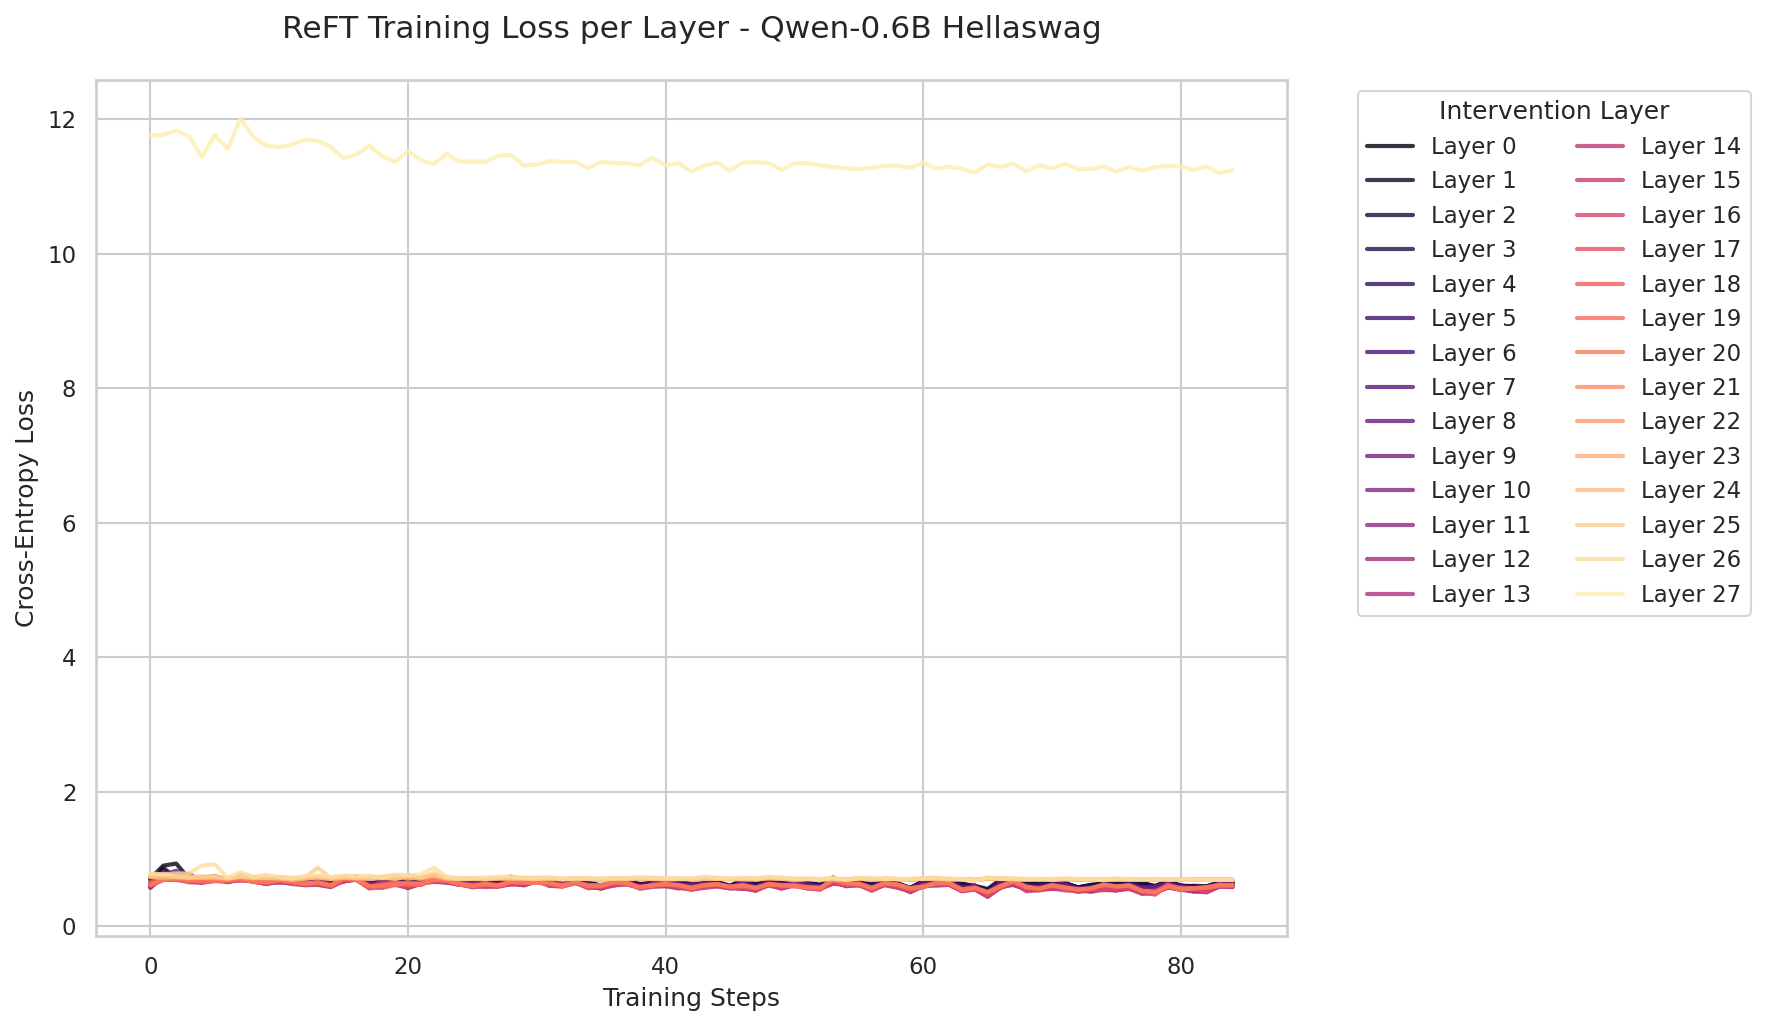

In [24]:
data = prepare_data_for_plot('qwen-hellaswag', metric='epoch_losses', truncate_data=[(5, None)])
plot_layer_losses(data, model_name="Qwen-0.6B", task_name="Hellaswag")

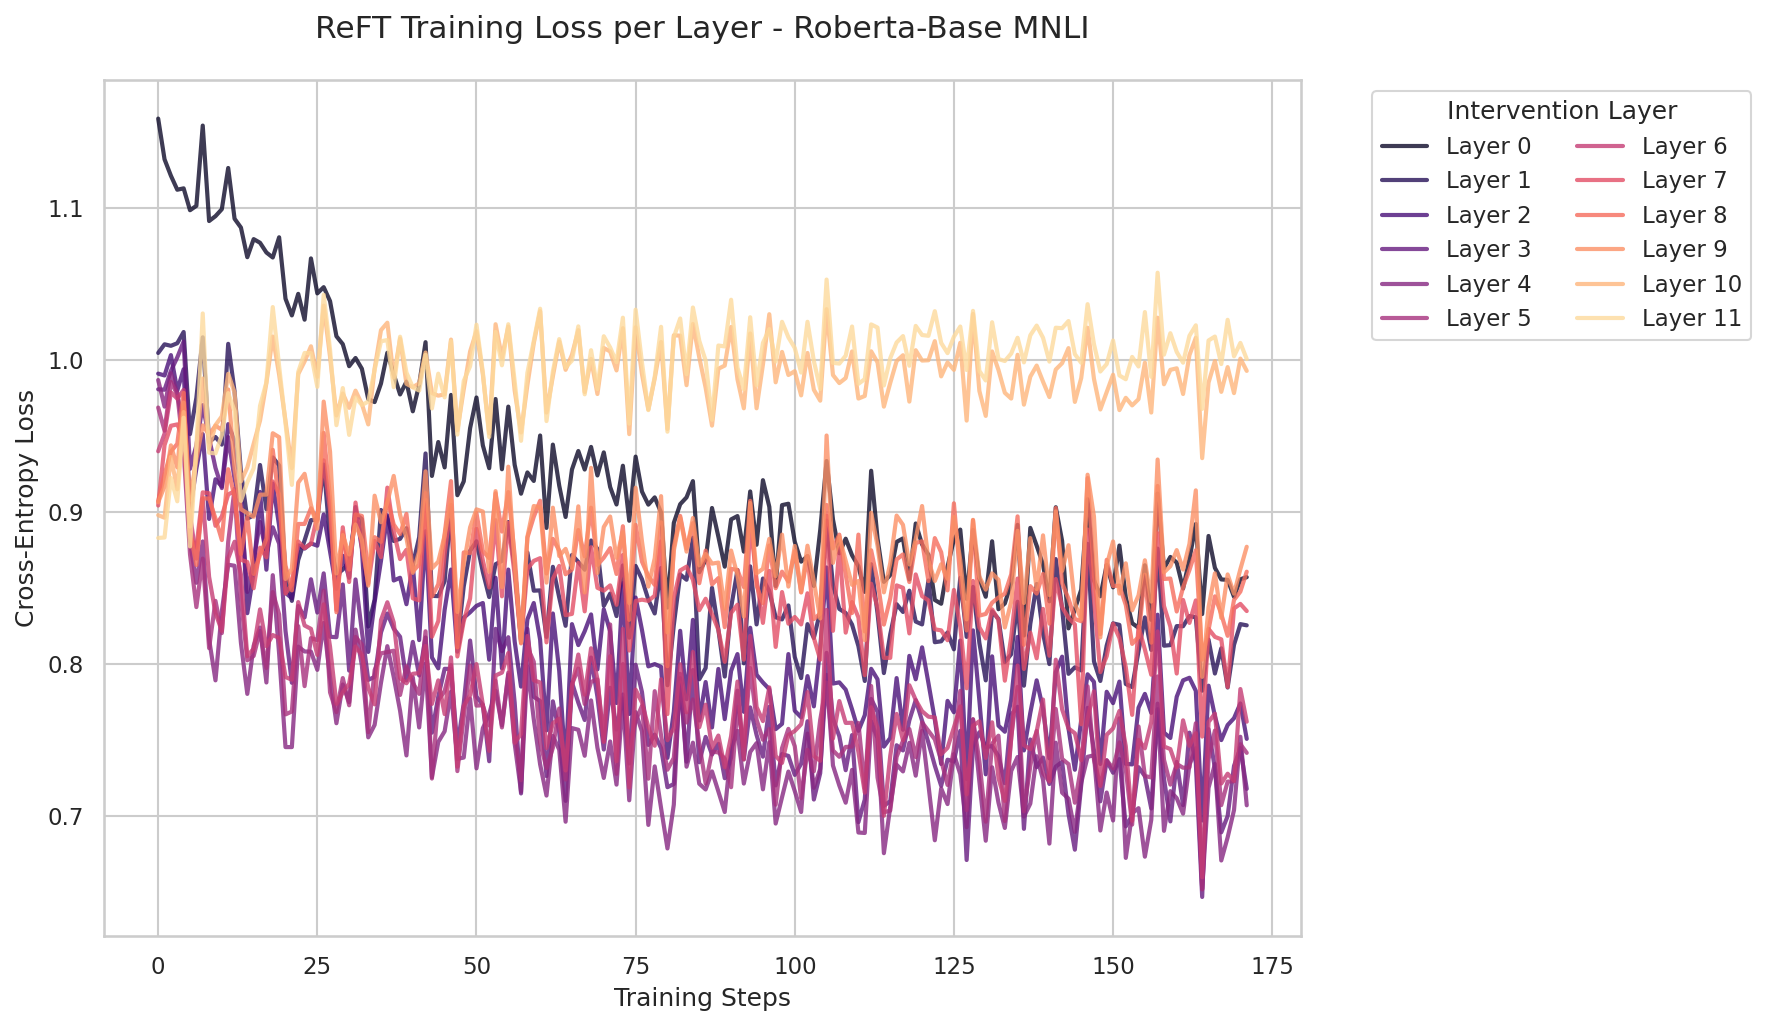

In [25]:
data = prepare_data_for_plot('roberta-mnli', metric='epoch_losses')
plot_layer_losses(data, model_name="Roberta-Base", task_name="MNLI")

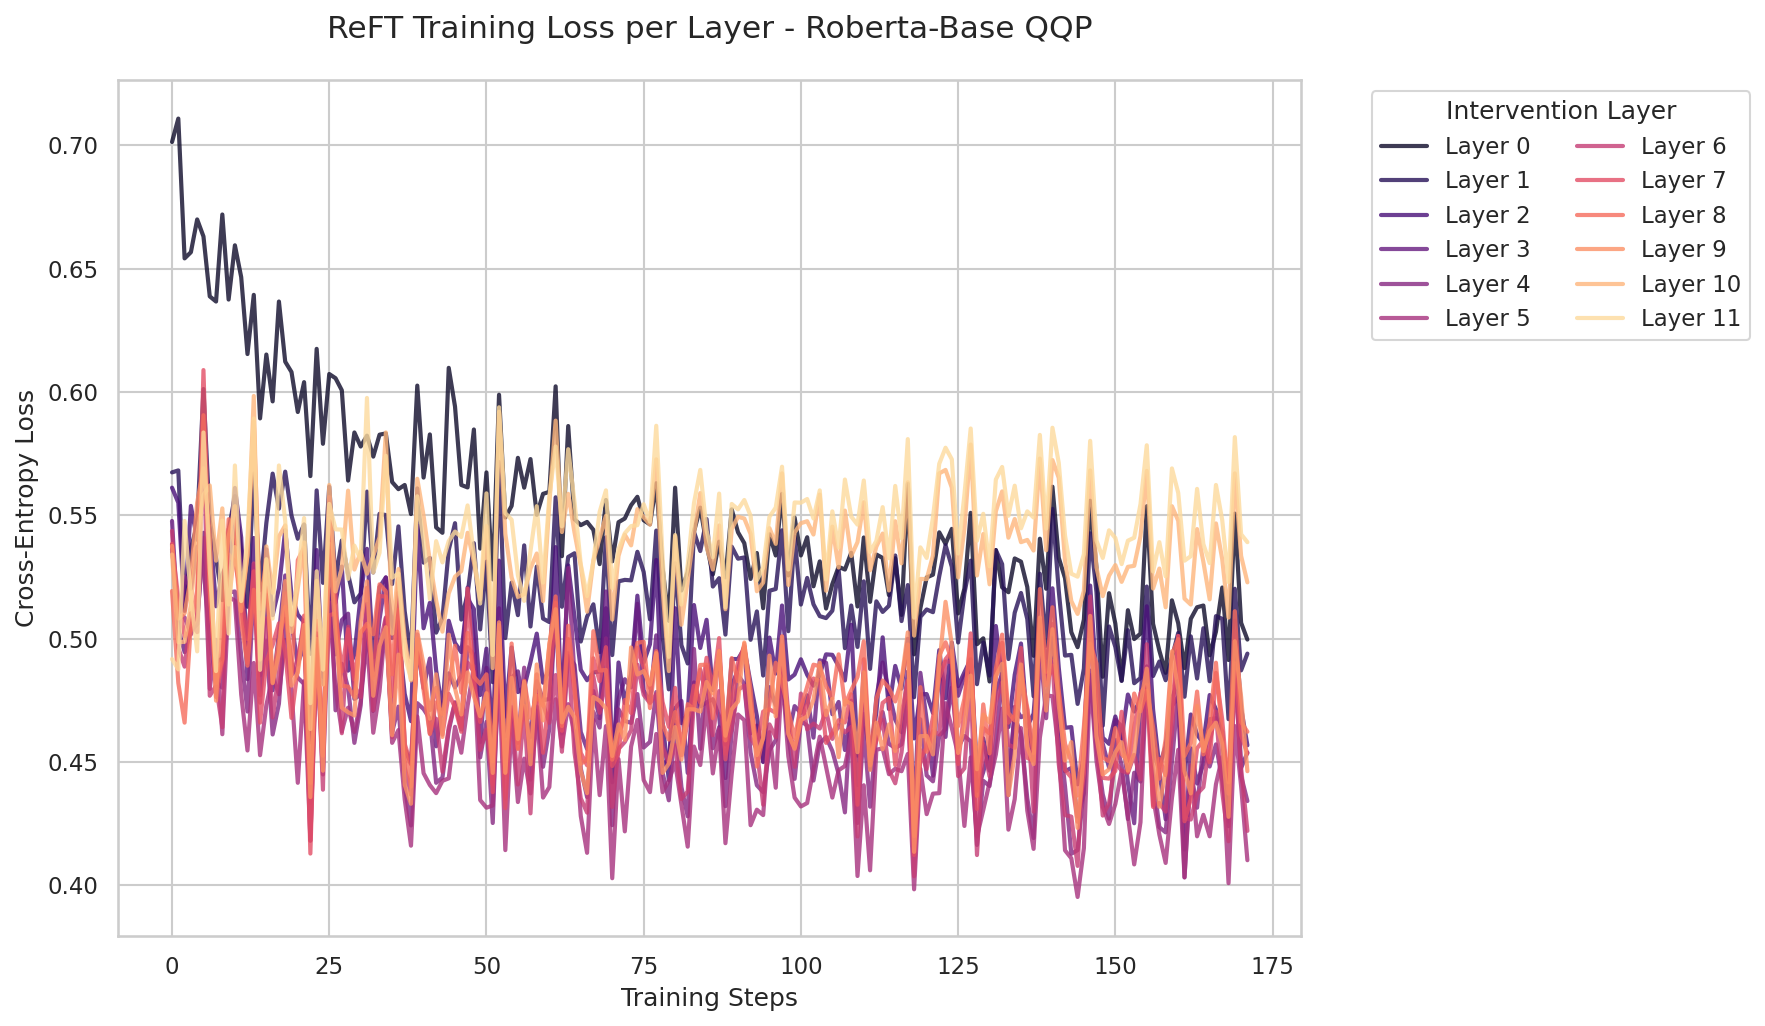

In [26]:
data = prepare_data_for_plot('roberta-qqp', metric='epoch_losses')
plot_layer_losses(data, model_name="Roberta-Base", task_name="QQP")

## Gradient Norms

In [27]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

def plot_layer_grad_norms(grad_data_dict, model_name="Model", save=False):
    """
    grad_data_dict: { "Layer 0": [list of norms], "Layer 1": [...] }
    """
    plt.figure(figsize=(12, 6))
    
    palette = sns.color_palette("viridis", len(grad_data_dict))
    
    for i, (layer_name, norms) in enumerate(grad_data_dict.items()):
        steps = np.arange(len(norms))
        sns.lineplot(
            x=steps, 
            y=norms, 
            label=layer_name, 
            color=palette[i], 
            alpha=0.7, 
            linewidth=1.5
        )

    title = f"Gradient Norm Trends Across Layers - {model_name}"
    plt.title(title, fontsize=15, pad=20)
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Gradient Norm Magnitude", fontsize=12)
    
    # Use log scale if initial peaks are massive compared to stable regions
    plt.yscale('log')
    
    if len(grad_data_dict) > 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    else:
        plt.legend(title="Layers", loc='upper right')

    plt.tight_layout()
    plt.show()

    if not save:
        return

    plt.savefig(f"{title}.png", dpi=300, bbox_inches="tight")

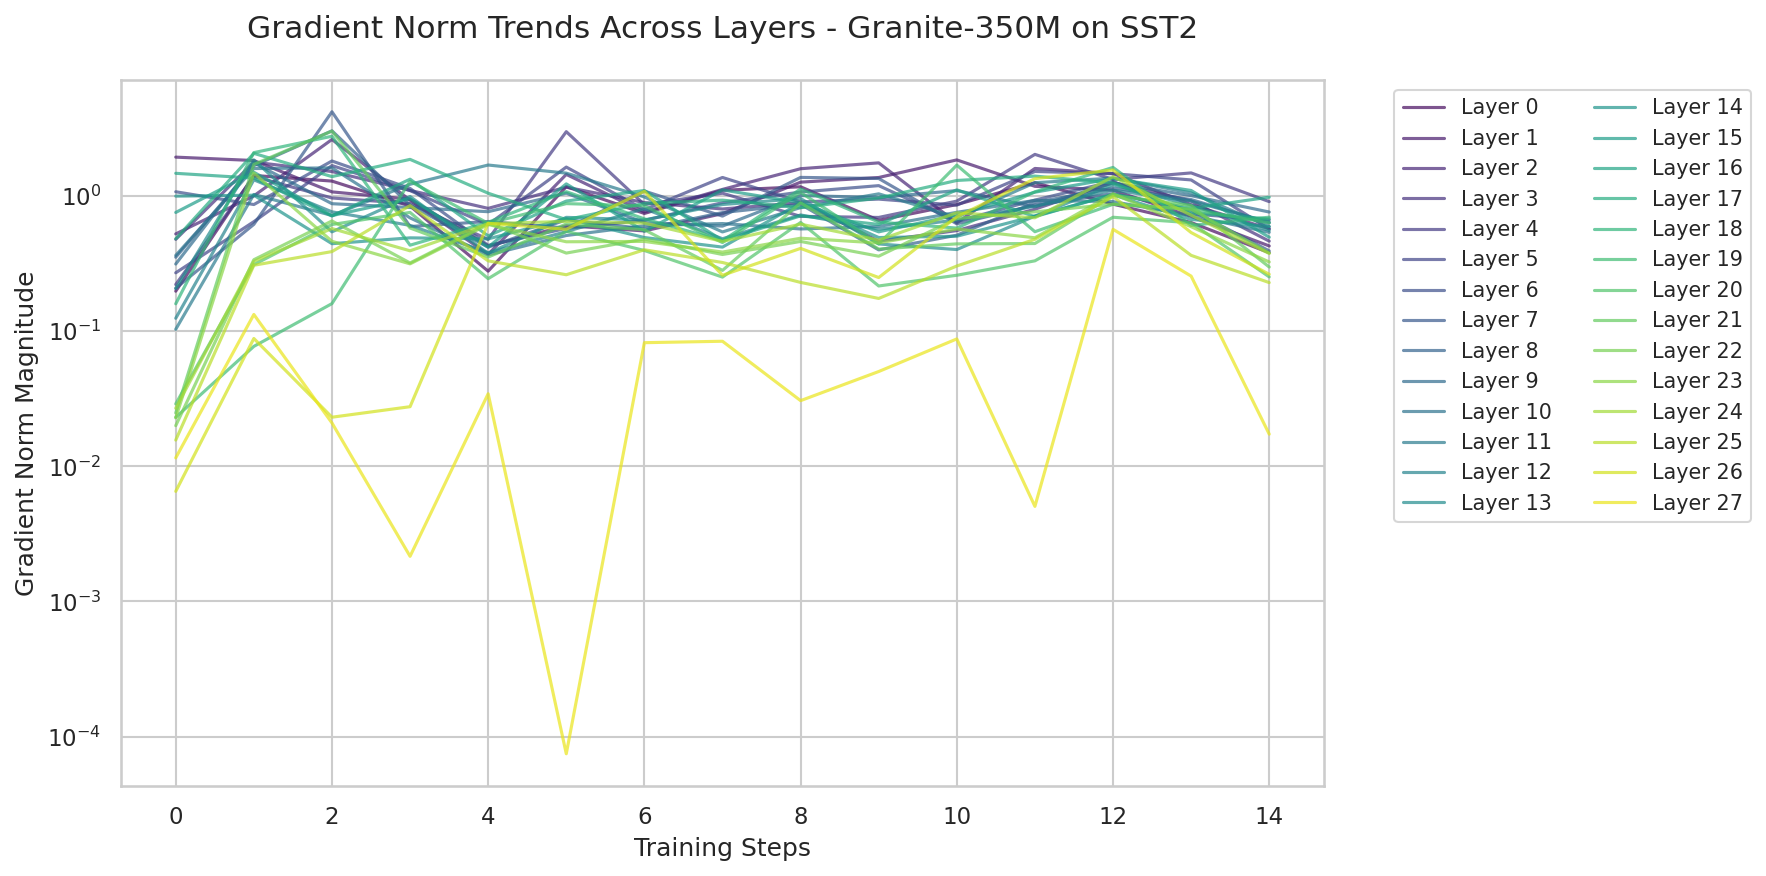

In [28]:
data = prepare_data_for_plot('granite-sst2')
plot_layer_grad_norms(data, model_name="Granite-350M on SST2")

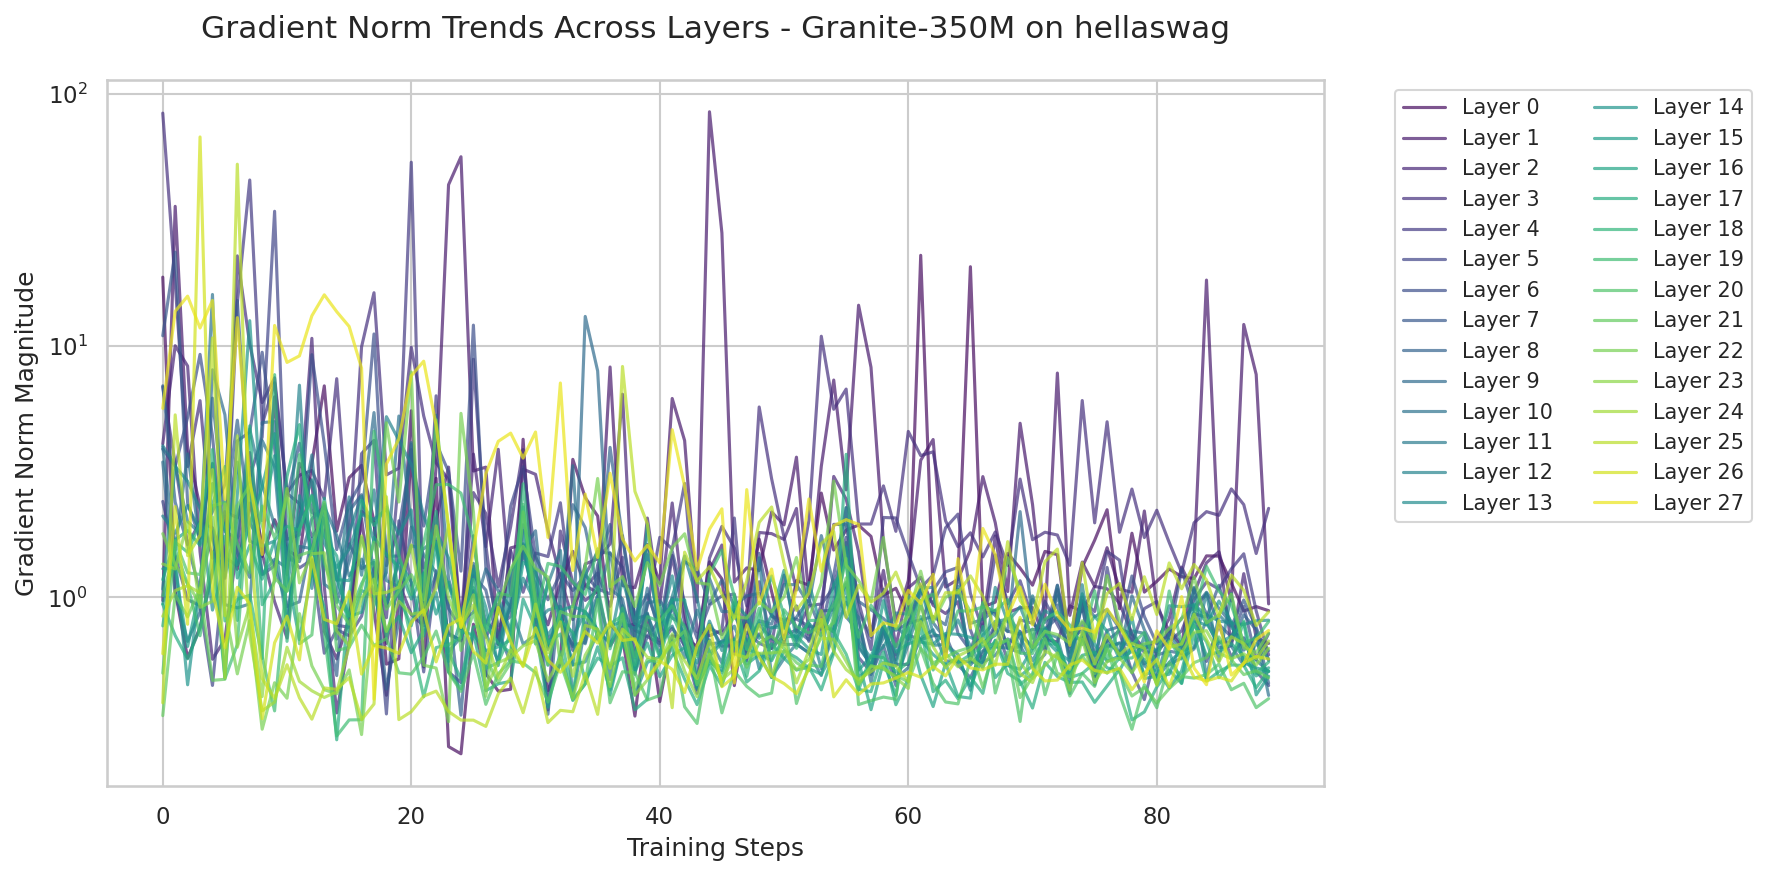

In [29]:
data = prepare_data_for_plot('granite-hellaswag')
plot_layer_grad_norms(data, model_name="Granite-350M on hellaswag")

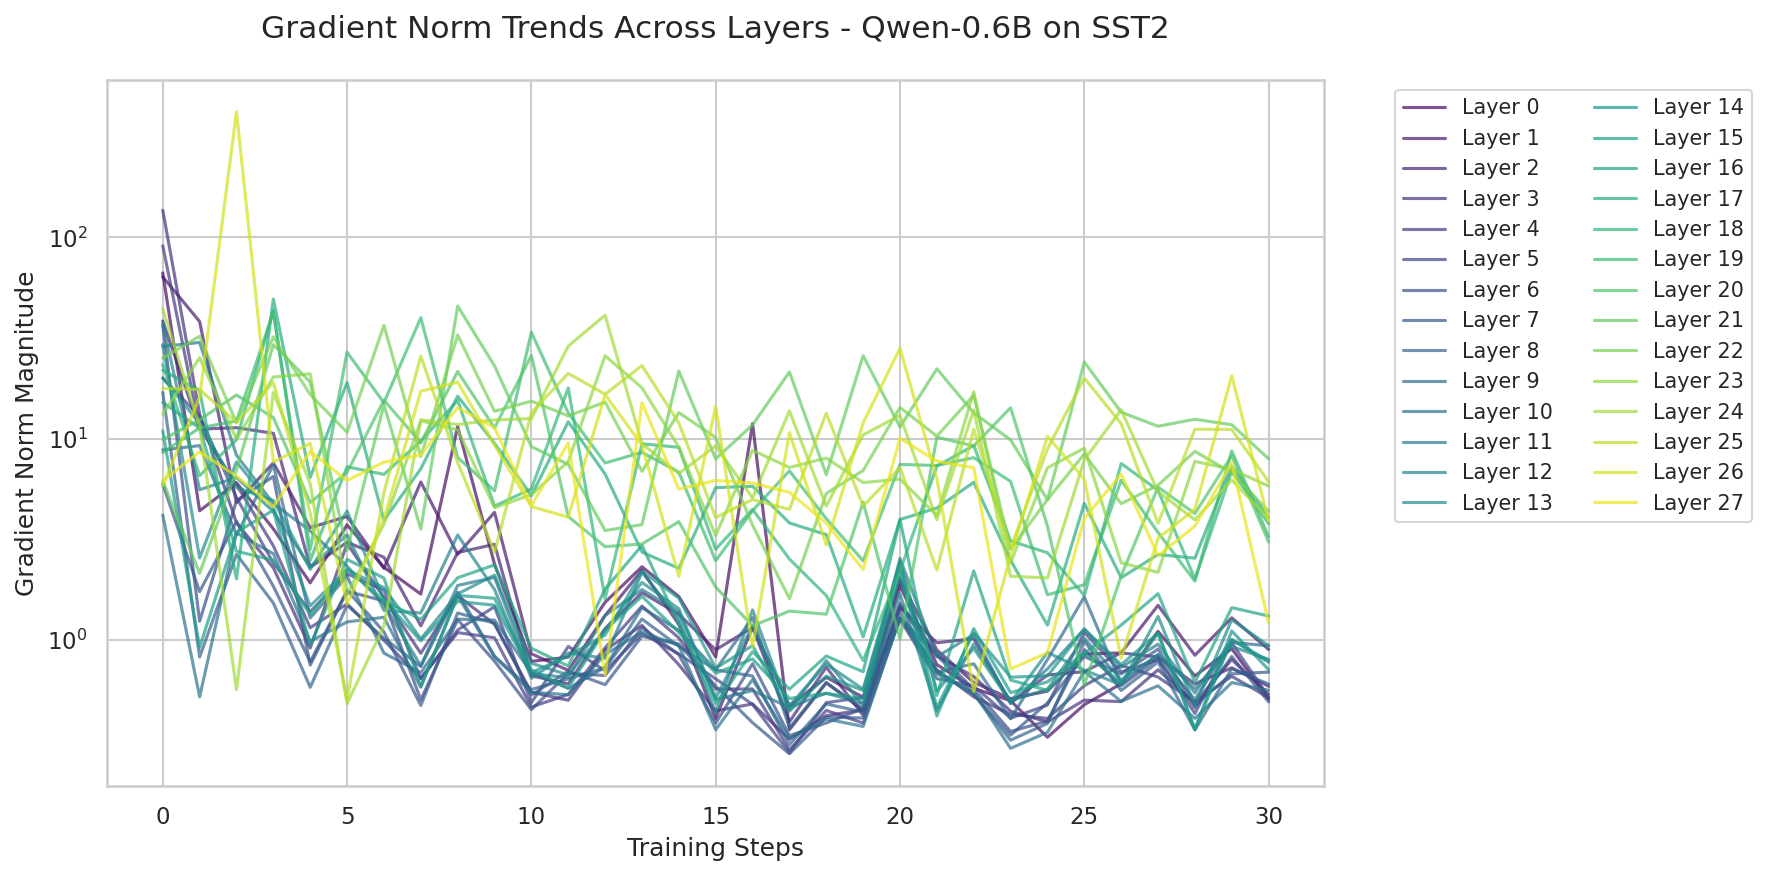

In [30]:
data = prepare_data_for_plot('qwen-sst2')
plot_layer_grad_norms(data, model_name="Qwen-0.6B on SST2")

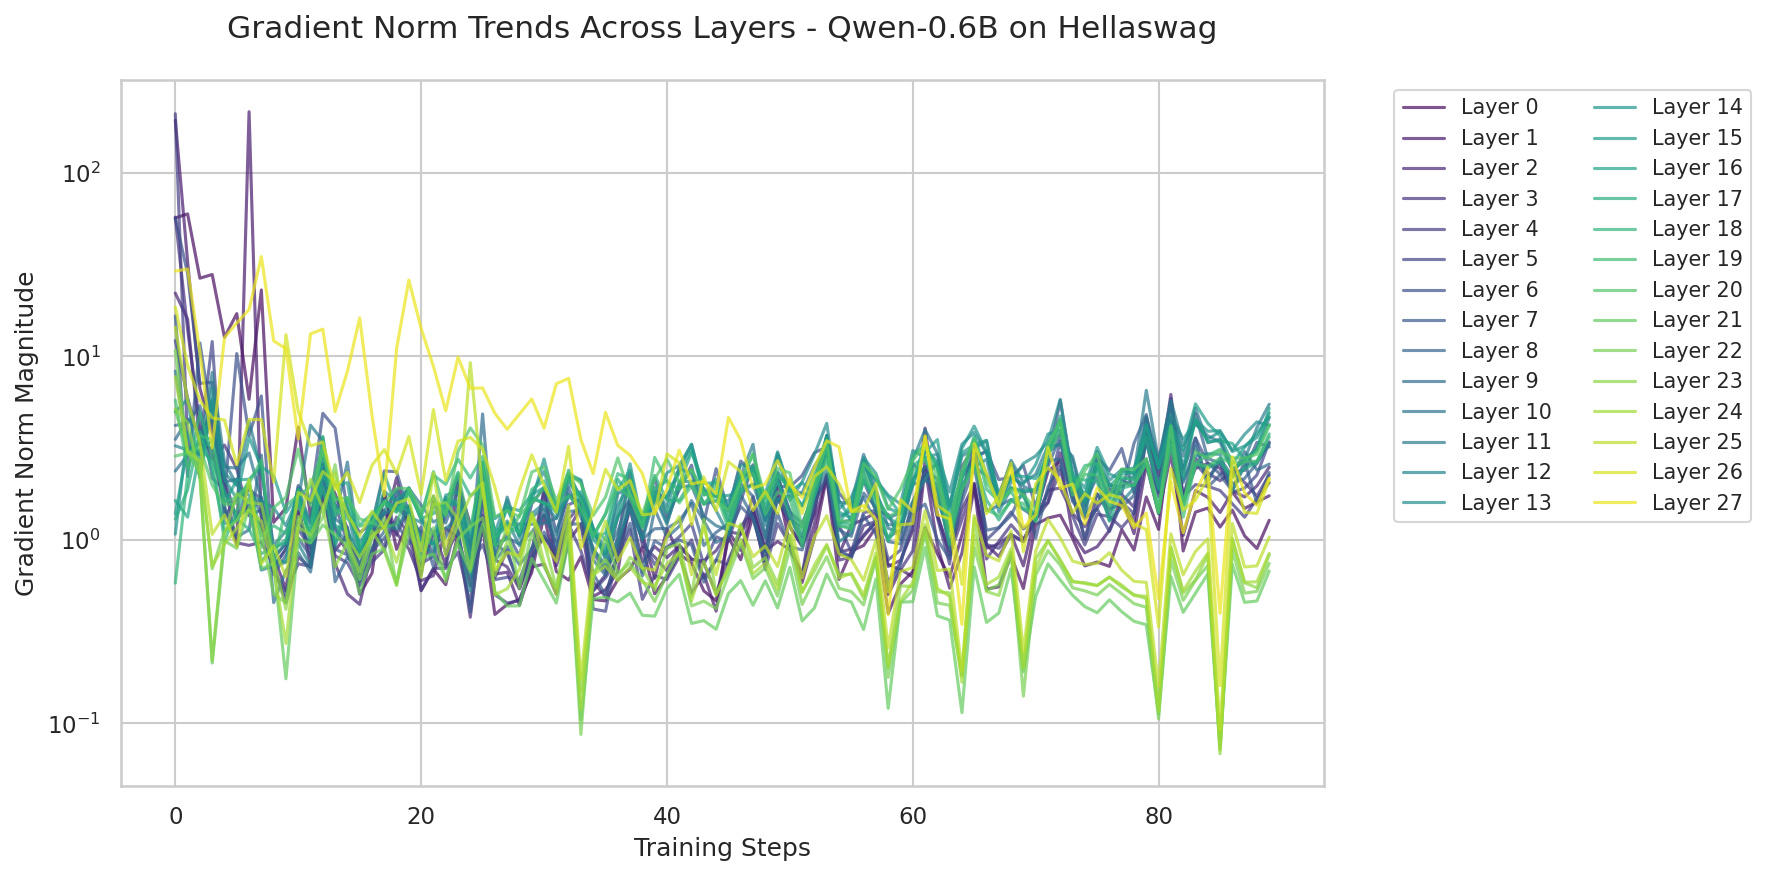

<Figure size 960x720 with 0 Axes>

In [31]:
data = prepare_data_for_plot('qwen-hellaswag')
plot_layer_grad_norms(data, model_name="Qwen-0.6B on Hellaswag", save=True)

In [32]:
!ls "{WEIGHTS_PATH}/sst2-granite/sst2_layer_1"

checkpoint-315


# Loading Weights

In [33]:
class PatchedReftTrainerForCausalLM(pyreft.ReftTrainerForCausalLM):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        return super().compute_loss(model, inputs, return_outputs=return_outputs)

model_name = "Qwen/Qwen3-0.6B"

device = Accelerator().device

model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

device, summary(model)

LOW_RANK_DIMENSION=8

def reft_configured_model(layer_index):
    reft_config = pyreft.ReftConfig(representations=[{
        "layer": layer_index,
        "component": f"model.layers[{layer_index}].output",  # explicit path, bypasses registry
        "low_rank_dimension": LOW_RANK_DIMENSION,
        "intervention": pyreft.LoreftIntervention(
            embed_dim=model.config.hidden_size, low_rank_dimension=LOW_RANK_DIMENSION
        )
    }])

    reft_model = pyreft.get_reft_model(model, reft_config)
    reft_model.set_device(device)

    reft_model.print_trainable_parameters()

    return reft_model

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

In [34]:
class WeightAnalyzer:
    @classmethod
    def intervention_path(cls, model, task, layer, checkpoint=1800):
        return f"{WEIGHTS_PATH}/{task}-{model}/{task}_layer_{layer}/checkpoint-{checkpoint}/intervenable_model"

    @classmethod
    def load_weights(cls, model, task, layer, checkpoint=1800):
        path = cls.intervention_path(model, task, layer, checkpoint=checkpoint)
        
        files = os.listdir(path)
        weight_file = [
            f for f in files
            if f.endswith(".bin") and "pytorch_model" not in f
        ][0]
        
        weights = torch.load(
            os.path.join(path, weight_file),
            map_location=torch.device("cpu")
        )
    
        return weights['weight'], weights['bias'], weights['rotate_layer']

    @classmethod
    def frobenius_norm(cls, weights):
        return torch.norm(weights, p="fro")

    @classmethod
    def frobenius_norm_full(cls, weights, bias, rotate_layer):
        return (
            torch.norm(weights, "fro") +
            torch.norm(bias, 2) +
            torch.norm(rotate_layer, "fro")
        )

    @classmethod
    def total_intervention_capacity(cls, *args, **kwargs):
        return cls.frobenius_norm_full(*args, **kwargs)

    @classmethod
    def deviation_from_identity(cls, R): # R is rotate_layer
        I_approx = R.T @ R
        deviation = torch.norm(I_approx - torch.eye(I_approx.shape[0]))

        return deviation

    @classmethod
    def direction_strength(cls, R):
        col_norms = torch.norm(R, dim=0)

        return col_norms

    @classmethod
    def effective_rank(cls, R):
        R = R.float()
        U, S, Vh = torch.svd(R)
        
        p = S / S.sum()
        entropy = -(p * torch.log(p + 1e-8)).sum()
        effective_rank = torch.exp(entropy)
        
        return effective_rank

    @classmethod
    def weight_stats_for_layer(cls, model, task, layer, checkpoint=1800):
        weights, bias, rotate_layer = cls.load_weights(model, task, layer, checkpoint=checkpoint)

        data = {}

        data['total_intervention_capacity'] = cls.total_intervention_capacity(weights, bias, rotate_layer).item()
        data['rotate_deviation_from_identity'] = cls.deviation_from_identity(rotate_layer).item()
        data['direction_strength'] = cls.direction_strength(rotate_layer).tolist()
        data['rotate_effective_rank'] = cls.effective_rank(rotate_layer).item()
        data['weights_norm'] = cls.frobenius_norm(weights).item()
        data['weights_effective_rank'] = cls.effective_rank(weights).item()

        return data

    @classmethod
    def weight_stats_for_layers(cls, model, task, layer_count=28, checkpoint=1800):
        data = {}
        
        for i in range(layer_count):
            data[i] = cls.weight_stats_for_layer(model, task, i, checkpoint=checkpoint)

        data = dict(sorted(data.items()))

        return data

In [35]:
args_list = [
    ('qwen', 'hellaswag', 28, 1800),
    ('granite', 'hellaswag', 28, 1800),
    ('qwen', 'sst2', 28, 625),
    ('granite', 'sst2', 28, 315)
]

data_keys = ['total_intervention_capacity', 'rotate_deviation_from_identity', 'direction_strength', 'rotate_effective_rank', 'weights_norm', 'weights_effective_rank']

for args in args_list:
    model, task, _, _ = args
    data = WeightAnalyzer.weight_stats_for_layers(*args).values()
    
    key = f"{model}-{task}"
    
    for dk in data_keys:
        dataframes[key][dk] = [d[dk] for d in data]

In [36]:
for key in decoder_models:
    df = dataframes[key]
    print(f"{key}:")
    for dk in [d for d in data_keys if d != 'direction_strength']:
        pearson_corr, _ = pearsonr(df['score'], df[dk])
        # spearman_corr, _ = pearsonr(df['score'], df[dk])

        print(f"accuracy vs {dk}:\n\tPearson: {pearson_corr}")

    print("\n\n")

qwen-sst2:
accuracy vs total_intervention_capacity:
	Pearson: -0.4607707330973209
accuracy vs rotate_deviation_from_identity:
	Pearson: 0.2742336822167194
accuracy vs rotate_effective_rank:
	Pearson: 0.08393096227899381
accuracy vs weights_norm:
	Pearson: -0.49052500428611084
accuracy vs weights_effective_rank:
	Pearson: 0.3787751020886768



qwen-hellaswag:
accuracy vs total_intervention_capacity:
	Pearson: 0.7875307161305248
accuracy vs rotate_deviation_from_identity:
	Pearson: -0.10877848985354999
accuracy vs rotate_effective_rank:
	Pearson: -0.045383502110805565
accuracy vs weights_norm:
	Pearson: 0.7920823989990593
accuracy vs weights_effective_rank:
	Pearson: -0.5077199020782645



granite-sst2:
accuracy vs total_intervention_capacity:
	Pearson: -0.3747591681495086
accuracy vs rotate_deviation_from_identity:
	Pearson: 0.03778935747038725
accuracy vs rotate_effective_rank:
	Pearson: 0.050911217746495145
accuracy vs weights_norm:
	Pearson: -0.3517571130215373
accuracy vs weights_ef